# Expressibility Benchmark

This notebook benchmarks the expressibility of IQC variants by comparing empirical fidelity distributions against the Haar reference and reporting KL divergence plus relative expressibility across scaling regimes.

In [7]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
source_file = HERE / 'iqc_expr_benchmark.py'
if not source_file.exists():
    raise FileNotFoundError('Could not find iqc_expr_benchmark.py in the current directory.')

source_dir = source_file.parent
if str(source_dir) not in sys.path:
    sys.path.insert(0, str(source_dir))

from iqc_expr_benchmark import (
    BenchmarkConfig,
    run_benchmark,
)


def model_display_name(result):
    model_name = result["model"]
    n_target_qubits = int(result["n_target_qubits"])
    target_space_dim = 2**n_target_qubits
    env_space_dim = int(result["dimension"]) // target_space_dim

    if model_name == "iqc_zhangetal":
        return "IQC"
    if model_name == "iqc_britoetal":
        return "IQC-AIL"
    if model_name == "iqc_alfa":
        return "IQC-$\\alpha$"
    if (
        model_name.startswith("iqc_multidimensional_")
    ):
        return f"IQC-multi-{env_space_dim}"
    return model_name

## Results on Expr and Relative Expressibility

Results for n_features=4, n_pairs=10000, n_bins=75:
          model  global dimension  KL(P || Haar)  Expr_idle  Rel Expr
0           IQC                 8      14.222509  30.222417  0.753758
1  IQC-$\alpha$                 8       8.260590  30.222417  1.297088
2       IQC-AIL                 8       3.469879   5.724525  0.500640
3   IQC-multi-2                 4       0.929224  12.952464  2.634691
4   IQC-multi-4                 8       2.539594  30.222417  2.476580
5   IQC-multi-8                16       6.408019  64.762322  2.313174
Results for n_features=6, n_pairs=10000, n_bins=75:
          model  global dimension  KL(P || Haar)  Expr_idle  Rel Expr
0           IQC                12      22.010716  47.492369  0.769040
1  IQC-$\alpha$                12      12.820306  47.492369  1.309539
2       IQC-AIL                12       5.424233   8.523419  0.451941
3   IQC-multi-2                 4       0.477813  12.952464  3.299822
4   IQC-multi-4                 8       1.465655  30.222

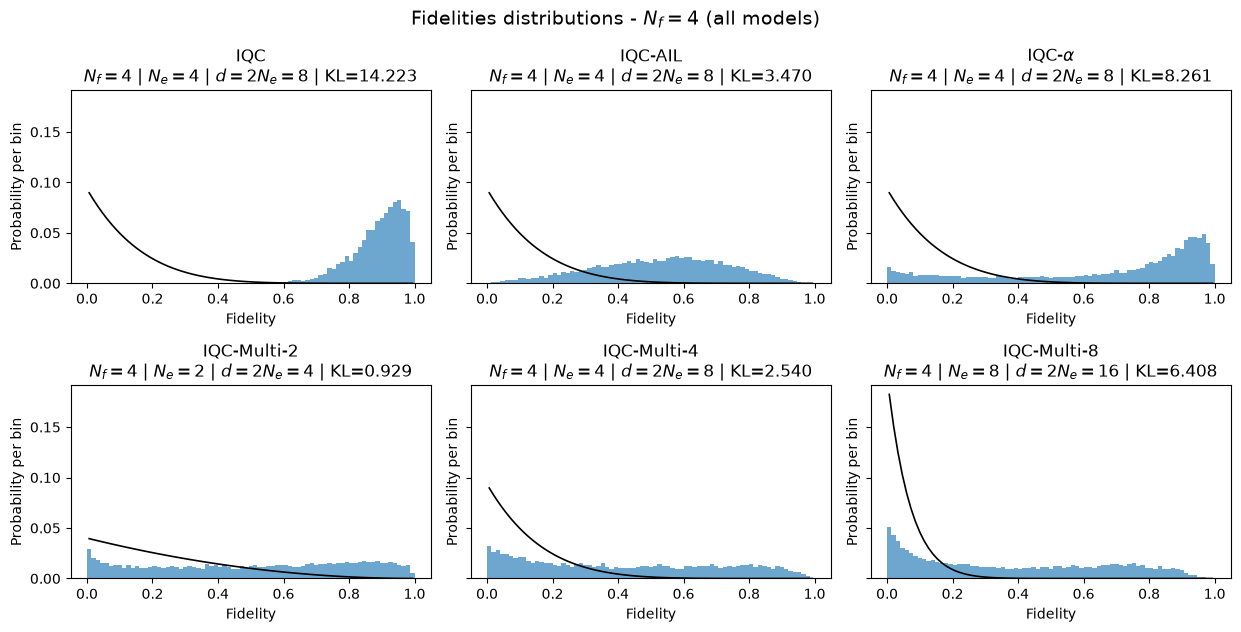

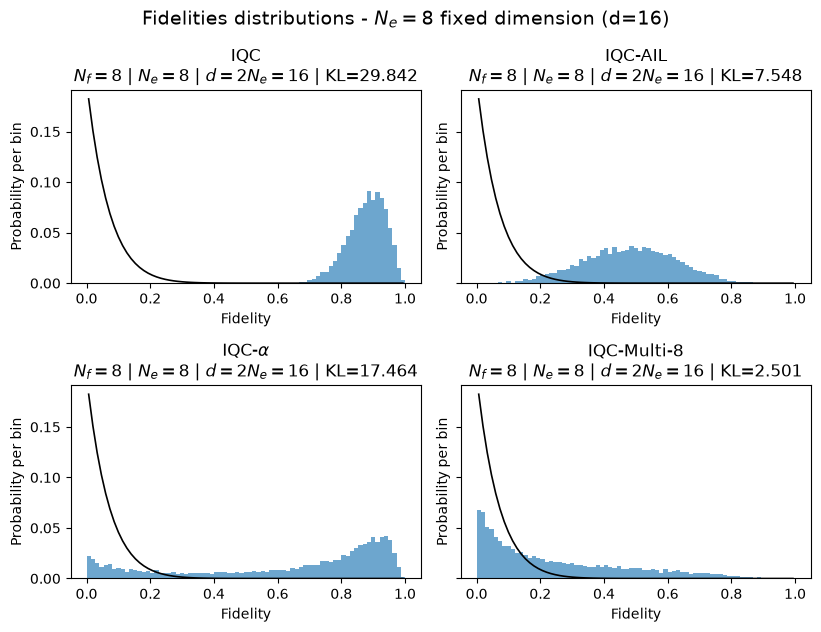

Optional fixed-dimension N_f=6 figure not generated: IQC-Multi-6 model unavailable.


In [8]:
NF_VALUES = (4, 6, 8)
REQUESTED_MODELS = (
    'iqc_zhangetal',
    'iqc_britoetal',
    'iqc_alfa',
    'iqc_multidimensional_2',
    'iqc_multidimensional_4',
    'iqc_multidimensional_8',
)
MODEL_LABELS = {
    'iqc_zhangetal': 'IQC',
    'iqc_britoetal': 'IQC-AIL',
    'iqc_alfa': 'IQC-$\\alpha$',
    'iqc_multidimensional_2': 'IQC-Multi-2',
    'iqc_multidimensional_4': 'IQC-Multi-4',
    'iqc_multidimensional_8': 'IQC-Multi-8',
}

output_dir = source_dir
output_dir.mkdir(parents=True, exist_ok=True)

n_pairs = 10_000 # 1_000 for benchmarks, 10_000 for final results

def env_qubits_from_result(result, n_features):
    model_name = result['model']
    if model_name in ('iqc_zhangetal', 'iqc_britoetal', 'iqc_alfa'):
        return int(n_features)
    if model_name.startswith('iqc_multidimensional_'):
        return int(model_name.replace('iqc_multidimensional_', '').split('_')[0])
    n_target_qubits = int(result['n_target_qubits'])
    target_space_dim = 2 ** n_target_qubits
    return int(result['dimension']) // target_space_dim

def run_results_for_n_features(n_features, n_pairs=n_pairs, n_bins=75, seed=2026):
    local_config = BenchmarkConfig(
        n_features=n_features,
        n_pairs=n_pairs,
        n_bins=n_bins,
        seed=seed,
        randomize_alpha=True,
    )
    local_results = run_benchmark(local_config, models=REQUESTED_MODELS)
    by_model = {result['model']: result for result in local_results}
    filtered = [by_model[model] for model in REQUESTED_MODELS if model in by_model]

    summary = pd.DataFrame([
                {
                    'model': model_display_name(result),
                    'global dimension': result['dimension'],
                    'KL(P || Haar)': result['kld'],
                    'Expr_idle': result['expr_idle'],
                    'Rel Expr': result['relative_expr'],
                }
                for result in local_results
            ]).sort_values(['model']).reset_index(drop=True)
    print(f"Results for n_features={n_features}, n_pairs={n_pairs}, n_bins={n_bins}:")
    print(summary)
    return local_config, filtered

results_by_nf = {}
configs_by_nf = {}
for n_features in NF_VALUES:
    local_config, local_results = run_results_for_n_features(n_features)
    configs_by_nf[n_features] = local_config
    results_by_nf[n_features] = local_results

def plot_selected_results(group_results, n_features, title, filename, n_cols=3):
    if not group_results:
        print(f'No results available for: {title}')
        return None

    local_config = configs_by_nf[n_features]
    n_rows = int(np.ceil(len(group_results) / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.2 * n_cols, 3.2 * n_rows),
        sharey=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for index, result in enumerate(group_results):
        axis = axes[index]
        centers = (result['bin_edges'][:-1] + result['bin_edges'][1:]) / 2
        axis.bar(centers, result['empirical'], width=1 / local_config.n_bins, alpha=0.65)
        axis.plot(centers, result['haar'], color='black', linewidth=1.2)
        model_name = result['model']
        display_name = MODEL_LABELS.get(model_name, model_display_name(result))
        n_env_qubits = env_qubits_from_result(result, n_features)
        d_value = 2 * n_env_qubits
        axis.set_title(
            f"{display_name}\n$N_f={n_features}$ | $N_e={n_env_qubits}$ | $d=2N_e={d_value}$ | KL={result['kld']:.3f}"
        )
        axis.set_xlabel('Fidelity')
        axis.set_ylabel('Probability per bin')

    for index in range(len(group_results), len(axes)):
        axes[index].axis('off')

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    output_path = output_dir / filename
    plt.savefig(output_path, dpi=600)
    plt.show()
    return output_path

# 1) Fidelity distributions for N_f=4 (all 6 models).
models_nf4 = [
    'iqc_zhangetal',
    'iqc_britoetal',
    'iqc_alfa',
    'iqc_multidimensional_2',
    'iqc_multidimensional_4',
    'iqc_multidimensional_8',
]
results_nf4_map = {result['model']: result for result in results_by_nf[4]}
results_nf4 = [results_nf4_map[model] for model in models_nf4 if model in results_nf4_map]
figure_nf4_path = plot_selected_results(
    results_nf4,
    n_features=4,
    title='Fidelities distributions - $N_f=4$ (all models)',
    filename='fidelities_distributions_nf4_all_models.pdf',
)


# 2) Fidelity distributions for N_e=8 with fixed global dimension d=16.
models_nf8_fixed = [
    'iqc_zhangetal',
    'iqc_britoetal',
    'iqc_alfa',
    'iqc_multidimensional_8',
]
results_nf8_map = {result['model']: result for result in results_by_nf[8]}
results_nf8_fixed = [results_nf8_map[model] for model in models_nf8_fixed if model in results_nf8_map]
figure_nf8_fixed_path = plot_selected_results(
    results_nf8_fixed,
    n_features=8,
    title='Fidelities distributions - $N_e=8$ fixed dimension (d=16)',
    filename='fidelities_distributions_ne8_fixed_d16.pdf', 
    n_cols=2,
)

# Optional: analogous comparison for N_f=6 if IQC-Multi-6 is available.
models_nf6_fixed = [
    'iqc_zhangetal',
    'iqc_britoetal',
    'iqc_alfa',
    'iqc_multidimensional_6',
]
results_nf6_map = {result['model']: result for result in results_by_nf[6]}
if all(model in results_nf6_map for model in models_nf6_fixed):
    figure_nf6_fixed_path = plot_selected_results(
        [results_nf6_map[model] for model in models_nf6_fixed],
        n_features=6,
        title='Fidelities distributions - $N_f=6$ fixed dimension (d=12)',
        filename='fidelities_distributions_nf6_fixed_d12.pdf',
    )
else:
    figure_nf6_fixed_path = None
    print('Optional fixed-dimension N_f=6 figure not generated: IQC-Multi-6 model unavailable.')


### Scaling Plots

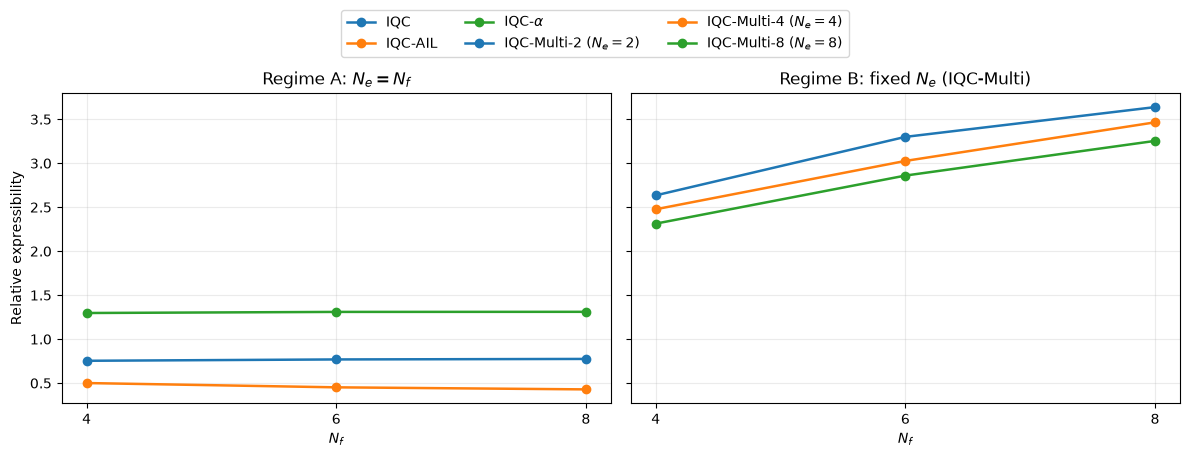

Generated figures:
- /Users/fabio/workspace/papers/parametrized_interactive_quantum_classifiers/code/expressibility/fidelities_distributions_nf4_all_models.pdf
- /Users/fabio/workspace/papers/parametrized_interactive_quantum_classifiers/code/expressibility/fidelities_distributions_ne8_fixed_d16.pdf
- N/A
- /Users/fabio/workspace/papers/parametrized_interactive_quantum_classifiers/code/expressibility/relative_expr_vs_nf_two_regimes.pdf


In [9]:
# 3) Relative expressibility versus N_f across two scaling regimes.
expr_rows = []
for n_features, local_results in results_by_nf.items():
    for result in local_results:
        model_name = result['model']
        expr_rows.append({
            'N_f': n_features,
            'model': model_name,
            'Relative Expr': result['relative_expr'],
        })
expr_df = pd.DataFrame(expr_rows)

panel_a_models = ['iqc_zhangetal', 'iqc_britoetal', 'iqc_alfa']
panel_b_models = ['iqc_multidimensional_2', 'iqc_multidimensional_4', 'iqc_multidimensional_8']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for model_name in panel_a_models:
    subset = expr_df[expr_df['model'] == model_name].sort_values('N_f')
    if subset.empty:
        continue
    axes[0].plot(
        subset['N_f'],
        subset['Relative Expr'],
        marker='o',
        linewidth=1.8,
        label=MODEL_LABELS[model_name]
    )
axes[0].set_title('Regime A: $N_e=N_f$')
axes[0].set_xlabel('$N_f$')
axes[0].set_ylabel('Relative expressibility')
axes[0].set_xticks(list(NF_VALUES))
axes[0].grid(alpha=0.25)
axes[0].legend()

for model_name in panel_b_models:
    subset = expr_df[expr_df['model'] == model_name].sort_values('N_f')
    if subset.empty:
        continue
    label = MODEL_LABELS[model_name]
    n_env = model_name.replace('iqc_multidimensional_', '').split('_')[0]
    axes[1].plot(
        subset['N_f'],
        subset['Relative Expr'],
        marker='o',
        linewidth=1.8,
        label=f'{label} ($N_e={n_env}$)'
    )
axes[1].set_title('Regime B: fixed $N_e$ (IQC-Multi)')
axes[1].set_xlabel('$N_f$')
axes[1].set_xticks(list(NF_VALUES))
axes[1].grid(alpha=0.25)
axes[1].legend()

# After plotting both panels
handles0, labels0 = axes[0].get_legend_handles_labels()
handles1, labels1 = axes[1].get_legend_handles_labels()

handles = handles0 + handles1
labels = labels0 + labels1

# Remove duplicates while preserving first occurrence
by_label = dict(zip(labels, handles))

fig.legend(
    by_label.values(),
    by_label.keys(),
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=True,
)

axes[0].legend().remove()
axes[1].legend().remove()

plt.tight_layout()
plt.subplots_adjust(top=.82)

figure_expr_vs_nf_path = output_dir / 'relative_expr_vs_nf_two_regimes.pdf'
plt.savefig(figure_expr_vs_nf_path, dpi=600, bbox_inches='tight')
plt.show()

print('Generated figures:')
print('-', figure_nf4_path)
print('-', figure_nf8_fixed_path)
print('-', figure_nf6_fixed_path if figure_nf6_fixed_path is not None else 'N/A')
print('-', figure_expr_vs_nf_path)